# **Deliverable 4: Feature Evaluation and Selection**


- Author: Tales Miguel Machado Pereira  
- RA: 140247
- Professor: Dr. Marcos Quiles

## A4 Instructions

Considering the QM9
- Use a subset of 5K molecules
- Use the DScribe package

1. Use same subset of Deliverable 3 (Data Visualization)

2. Compute the representations using the following methods: EV-CM and MBTR

3. Feature Evaluation / Feature Selection:
    - 3.1 Build a LASSO regressor for the bandgap property
    - 3.2 Rank the features
    - 3.3 Select the minimum subset of features to reach 95% of the accuracy considering the full set of features (for each MR)

4. Analysis
    - 4.1 Execution time for each method (full)
    - 4.2 Plot the accuracy degradation versus percentage of features
    - 4.3 Number of top features to reach 95% accuracy
    - 4.4 Plot scatter plots with the PCA and t-SNE

### **1. Setup**

Import libraries and configure environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from dscribe.descriptors import CoulombMatrix, MBTR

from tqdm.auto import tqdm
import random
import time

### **2. Load Subset**

Load the QM9 dataset and select the same subset of 5,000 molecules from Deliverable 3

In [2]:
qm9_df = pd.read_csv('qm9_complete_dataset.csv')

random.seed(42)
np.random.seed(42)

sample_size = 5000
if len(qm9_df) >= sample_size:
    qm9_sample = qm9_df.sample(n=sample_size, random_state=42).reset_index(drop=True)
else:
    qm9_sample = qm9_df.copy()

valid_mols = []
valid_smiles = []
valid_indices = []

for idx, smiles in tqdm(enumerate(qm9_sample['canonical_smiles']), total=len(qm9_sample)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        valid_mols.append(mol)
        valid_smiles.append(smiles)
        valid_indices.append(idx)

qm9_final = qm9_sample.iloc[valid_indices].reset_index(drop=True)

qm9_final[['gdb_id', 'canonical_smiles']].head()

100%|██████████| 5000/5000 [00:00<00:00, 42450.58it/s]



,gdb_id,canonical_smiles
0,3116,N#CC12CC1CO2
1,117880,COCC(O)C#CC=O
2,23434,COC1C2CC(=NO)C21
3,61956,C#CCOC(C)CC=O
4,98812,COC(=N)N1CCC1=N


### **3. Compute Molecular Representation**

Calculate EV-CM (Eigenvalue Coulomb Matrix) and MBTR (Many-Body Tensor Representation) representations using DScribe

In [5]:
from ase import Atoms

from rdkit.Chem import AllChem

species = ['H', 'C', 'N', 'O', 'F']

cm = CoulombMatrix(
    n_atoms_max=29,
    permutation='eigenspectrum'
)

mbtr = MBTR(
    species=species,
    geometry={'function': 'inverse_distance'},
    grid={'min': 0, 'max': 1, 'n': 100, 'sigma': 0.1},
    weighting={'function': 'exp', 'scale': 0.5, 'threshold': 1e-3},
    periodic=False,
    normalization='l2'
)

ase_mols = []               # atomic simulation environment (ASE) molecules list
for smiles in tqdm(valid_smiles, desc='Converting to ASE'):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        continue
    mol_h = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol_h, randomSeed=42)
    if mol_h.GetNumConformers() == 0:
        continue
    conf = mol_h.GetConformer()
    positions = conf.GetPositions()
    symbols = [atom.GetSymbol() for atom in mol_h.GetAtoms()]
    ase_mol = Atoms(symbols=symbols, positions=positions)
    ase_mols.append(ase_mol)

start_time = time.time()
evcm_features = cm.create(ase_mols, n_jobs=-1)
evcm_time = time.time() - start_time

start_time = time.time()
mbtr_features = mbtr.create(ase_mols, n_jobs=-1)
mbtr_time = time.time() - start_time

Converting to ASE: 100%|██████████| 5000/5000 [00:14<00:00, 345.05it/s]
/home/tales/miniconda3/lib/python3.13/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),
/home/tales/miniconda3/lib/python3.13/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),
/home/tales/miniconda3/lib/python3.13/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),
/home/tales/miniconda3/lib/python3.13/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),
/home/tales/miniconda3/lib/python3.13/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),
/home/tales/miniconda3/lib/python3.13/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),
/home/tale

### **4. Feature Evaluation and Selection**

Build LASSO regressor for bandgap property and perform feature selection

In [28]:
qm9_final_filtered = qm9_final.iloc[:len(ase_mols)].reset_index(drop=True)
# bandgap target (eV)
y = qm9_final_filtered['lumo_energy'].values - qm9_final_filtered['homo_energy'].values


def evaluate_features(X, y, representation_name):
    # sanitize and remove zero-variance features
    X_clean = np.where(np.isfinite(X), X, 0)
    zero_var_mask = np.var(X_clean, axis=0) != 0
    X_filtered = X_clean[:, zero_var_mask]

    # split before scaling to avoid leakage
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_filtered, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    # transform entire dataset with train scaler for downstream visualization
    X_scaled_all = scaler.transform(X_filtered)

    # full model for baseline R² and ranking
    lasso = Lasso(alpha=0.001, max_iter=10000, random_state=42)
    lasso.fit(X_train, y_train)

    y_pred = lasso.predict(X_test)
    r2_full = r2_score(y_test, y_pred)

    # feature ranking by absolute coefficient
    feature_importance = np.abs(lasso.coef_)
    ranked_indices = np.argsort(feature_importance)[::-1]

    # minimal number of features to reach 95% of r2_full
    r2_target = 0.95 * r2_full
    n95 = None
    for k in range(1, len(ranked_indices) + 1):
        sel = ranked_indices[:k]
        lasso_k = Lasso(alpha=0.001, max_iter=10000, random_state=42)
        lasso_k.fit(X_train[:, sel], y_train)
        r2_k = r2_score(y_test, lasso_k.predict(X_test[:, sel]))
        if r2_k >= r2_target:
            n95 = k
            break
    if n95 is None:
        n95 = len(ranked_indices)

    # build accuracy curve across number of features (sampled for efficiency if very high-dim)
    n_total = len(ranked_indices)
    max_points = 200
    if n_total <= max_points:
        k_grid = np.arange(1, n_total + 1)
    else:
        k_grid = np.unique(np.clip(np.round(np.linspace(1, n_total, max_points)).astype(int), 1, n_total))
        # ensure the n95 point is included for exact annotation
        if n95 not in set(k_grid.tolist()):
            k_grid = np.sort(np.unique(np.append(k_grid, n95)))

    r2_scores = []
    n_features_list = []
    for k in k_grid:
        sel = ranked_indices[:k]
        lasso_k = Lasso(alpha=0.001, max_iter=10000, random_state=42)
        lasso_k.fit(X_train[:, sel], y_train)
        r2_k = r2_score(y_test, lasso_k.predict(X_test[:, sel]))
        r2_scores.append(r2_k)
        n_features_list.append(int(k))

    return {
        'representation': representation_name,
        'r2_full': r2_full,
        'ranked_indices': ranked_indices,
        'feature_importance': feature_importance,
        'r2_scores': r2_scores,
        'n_features_list': n_features_list,
        'n_features_95': int(n95),
        'n_total_features': int(n_total),
        'X_scaled': X_scaled_all,
        'y': y
    }

# evaluate
evcm_results = evaluate_features(evcm_features, y, 'EV-CM')
mbtr_results = evaluate_features(mbtr_features, y, 'MBTR')


### **5. Analysis**

Execution time, accuracy degradation, and dimensionality reduction visualization

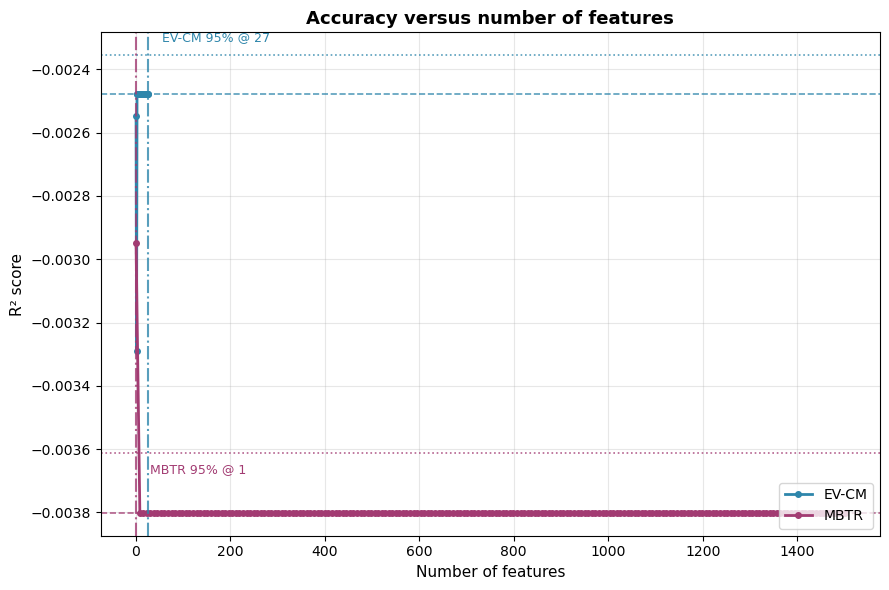

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

ax.plot(evcm_results['n_features_list'], evcm_results['r2_scores'], 'o-', linewidth=2, markersize=4, color='#2E86AB', label='EV-CM')
ax.plot(mbtr_results['n_features_list'], mbtr_results['r2_scores'], 'o-', linewidth=2, markersize=4, color='#A23B72', label='MBTR')

ax.axhline(y=evcm_results['r2_full'], color='#2E86AB', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axhline(y=mbtr_results['r2_full'], color='#A23B72', linestyle='--', linewidth=1.2, alpha=0.8)

ax.axhline(y=0.95 * evcm_results['r2_full'], color='#2E86AB', linestyle=':', linewidth=1.2, alpha=0.8)
ax.axhline(y=0.95 * mbtr_results['r2_full'], color='#A23B72', linestyle=':', linewidth=1.2, alpha=0.8)

ax.axvline(x=evcm_results['n_features_95'], color='#2E86AB', linestyle='-.', linewidth=1.5, alpha=0.8)
ax.axvline(x=mbtr_results['n_features_95'], color='#A23B72', linestyle='-.', linewidth=1.5, alpha=0.8)

ax.set_xlabel('Number of features', fontsize=11)
ax.set_ylabel('R² score', fontsize=11)
ax.set_title('Accuracy versus number of features', fontsize=13, fontweight='bold')

legend_labels = [
    f"EV-CM curve",
    f"MBTR curve",
]
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

# annotate minimal feature counts to reach 95% of full-model R²
ax.annotate(
    f"EV-CM 95% @ {evcm_results['n_features_95']}",
    xy=(evcm_results['n_features_95'], 0.95 * evcm_results['r2_full']),
    xytext=(10, 10), textcoords='offset points', color='#2E86AB', fontsize=9
)
ax.annotate(
    f"MBTR 95% @ {mbtr_results['n_features_95']}",
    xy=(mbtr_results['n_features_95'], 0.95 * mbtr_results['r2_full']),
    xytext=(10, -15), textcoords='offset points', color='#A23B72', fontsize=9
)

plt.tight_layout()
plt.show()

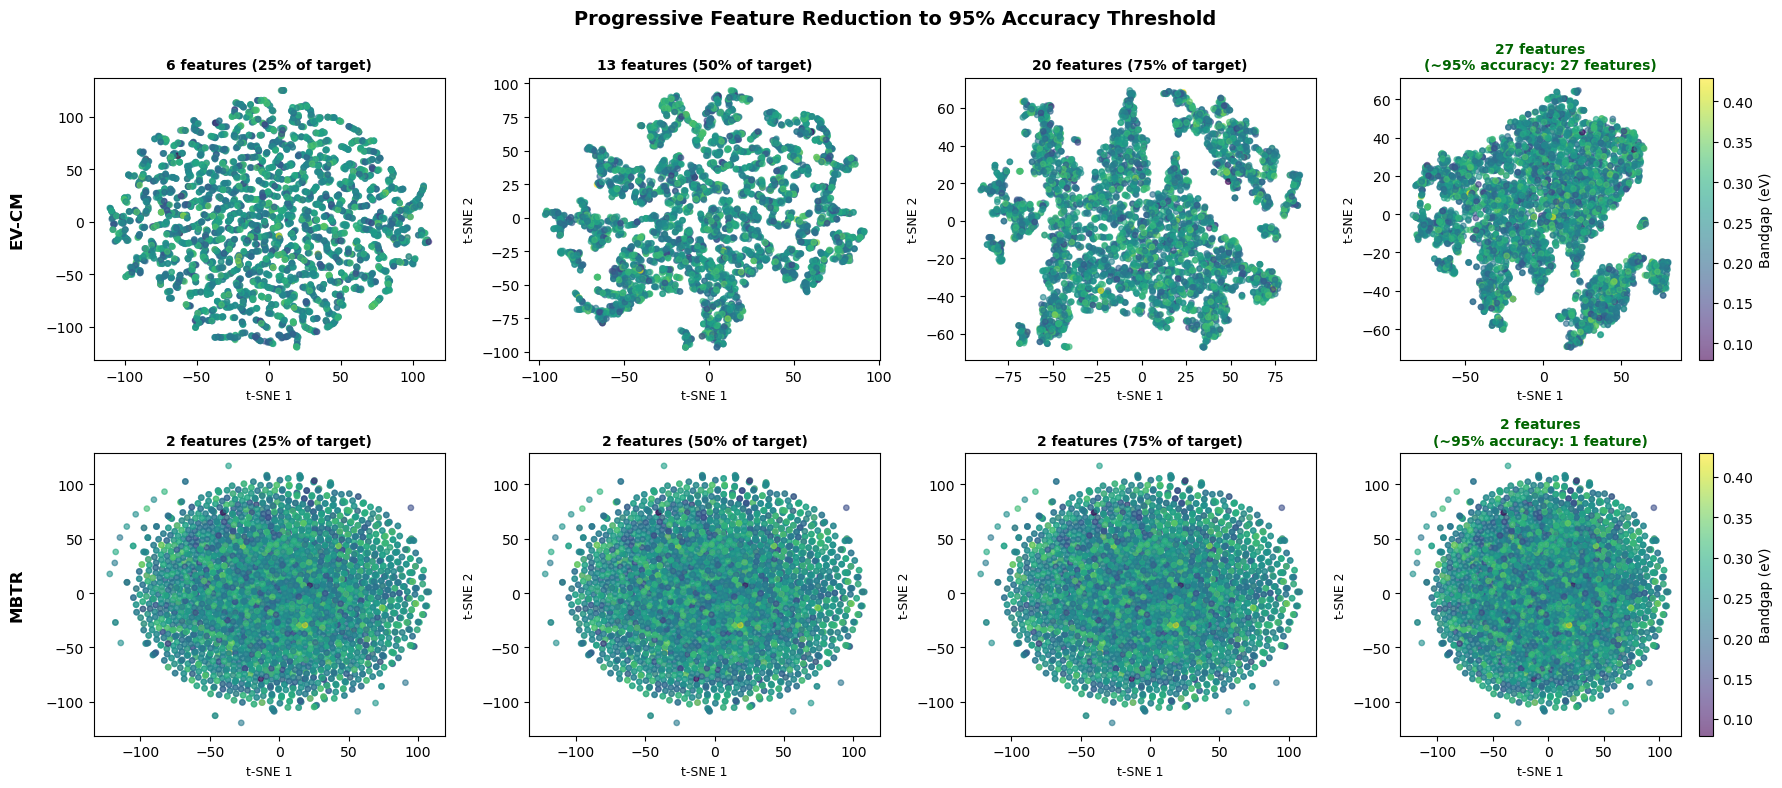

In [30]:
def get_reduced_features(results, n_features):
    selected_indices = results['ranked_indices'][:n_features]
    return results['X_scaled'][:, selected_indices]

evcm_95 = evcm_results['n_features_95']
mbtr_95 = max(2, mbtr_results['n_features_95'])

feature_checkpoints = [0.25, 0.5, 0.75, 1.0]

evcm_n_features_checkpoints = [max(2, int(evcm_95 * pct)) for pct in feature_checkpoints]
mbtr_n_features_checkpoints = [max(2, int(mbtr_95 * pct)) for pct in feature_checkpoints]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for idx, (n_feat, pct) in enumerate(zip(evcm_n_features_checkpoints, feature_checkpoints)):
    X_reduced = get_reduced_features(evcm_results, n_feat)
    
    tsne_temp = TSNE(n_components=2, random_state=42, perplexity=min(30, n_feat-1))
    X_tsne = tsne_temp.fit_transform(X_reduced)
    scatter = axes[0, idx].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.6, s=15)
    axes[0, idx].set_xlabel('t-SNE 1', fontsize=9)
    axes[0, idx].set_ylabel('t-SNE 2', fontsize=9)
    
    if idx == len(evcm_n_features_checkpoints) - 1:
        actual_95 = evcm_results['n_features_95']
        axes[0, idx].set_title(f'{n_feat} features\n(~95% accuracy: {actual_95} features)', fontsize=10, fontweight='bold', color='darkgreen')
    else:
        axes[0, idx].set_title(f'{n_feat} features ({pct*100:.0f}% of target)', fontsize=10, fontweight='bold')
    
    if idx == len(evcm_n_features_checkpoints) - 1:
        plt.colorbar(scatter, ax=axes[0, idx], label='Bandgap (eV)')

for idx, (n_feat, pct) in enumerate(zip(mbtr_n_features_checkpoints, feature_checkpoints)):
    X_reduced = get_reduced_features(mbtr_results, n_feat)
    
    tsne_temp = TSNE(n_components=2, random_state=42, perplexity=min(30, n_feat-1))
    X_tsne = tsne_temp.fit_transform(X_reduced)
    scatter = axes[1, idx].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.6, s=15)
    axes[1, idx].set_xlabel('t-SNE 1', fontsize=9)
    axes[1, idx].set_ylabel('t-SNE 2', fontsize=9)
    
    if idx == len(mbtr_n_features_checkpoints) - 1:
        actual_95 = mbtr_results['n_features_95']
        axes[1, idx].set_title(f'{n_feat} features\n(~95% accuracy: {actual_95} feature)', fontsize=10, fontweight='bold', color='darkgreen')
    else:
        axes[1, idx].set_title(f'{n_feat} features ({pct*100:.0f}% of target)', fontsize=10, fontweight='bold')
    
    if idx == len(mbtr_n_features_checkpoints) - 1:
        plt.colorbar(scatter, ax=axes[1, idx], label='Bandgap (eV)')

axes[0, 0].set_ylabel('EV-CM', fontsize=12, fontweight='bold', rotation=90, labelpad=15)
axes[1, 0].set_ylabel('MBTR', fontsize=12, fontweight='bold', rotation=90, labelpad=15)

fig.suptitle('Progressive Feature Reduction to 95% Accuracy Threshold', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

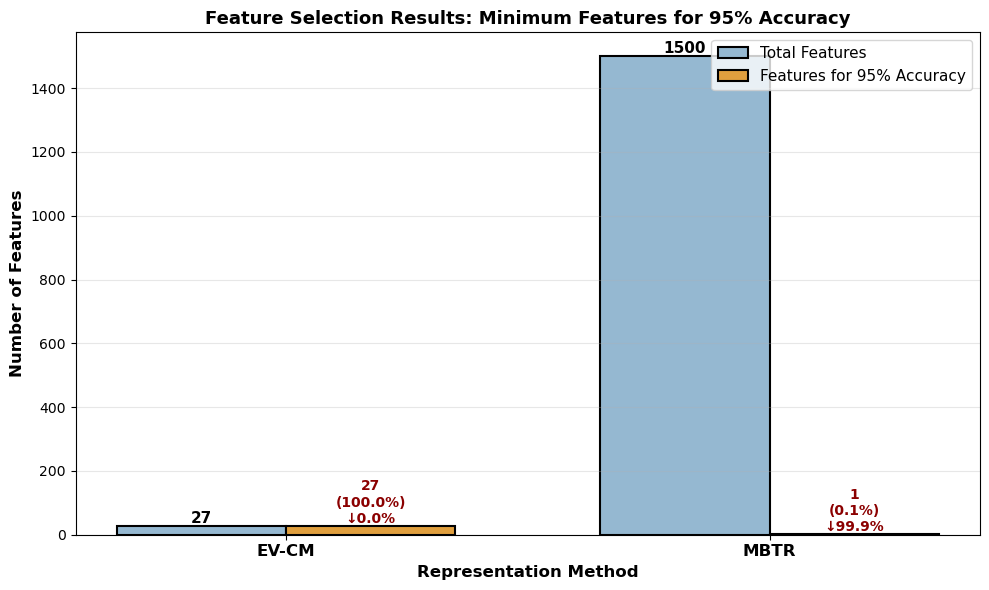

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

representations = ['EV-CM', 'MBTR']
n_features_95 = [evcm_results['n_features_95'], mbtr_results['n_features_95']]
total_features = [len(evcm_results['ranked_indices']), len(mbtr_results['ranked_indices'])]

x = np.arange(len(representations))
width = 0.35

bars1 = ax.bar(x - width/2, total_features, width, label='Total Features', color='#95B8D1', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, n_features_95, width, label='Features for 95% Accuracy', color='#E09F3E', edgecolor='black', linewidth=1.5)

for i, (bar, val) in enumerate(zip(bars1, total_features)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val}', ha='center', va='bottom', fontsize=11, fontweight='bold')

for i, (bar, val) in enumerate(zip(bars2, n_features_95)):
    pct = (val / total_features[i]) * 100
    reduction = ((total_features[i] - val) / total_features[i]) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{val}\n({pct:.1f}%)\n↓{reduction:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkred')

ax.set_xlabel('Representation Method', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Features', fontsize=12, fontweight='bold')
ax.set_title('Feature Selection Results: Minimum Features for 95% Accuracy', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(representations, fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [32]:
results_summary = pd.DataFrame({
    'Representation': ['EV-CM', 'MBTR'],
    'Execution Time (s)': [evcm_time, mbtr_time],
    'Full R² Score': [evcm_results['r2_full'], mbtr_results['r2_full']],
    'Total Features': [len(evcm_results['ranked_indices']), len(mbtr_results['ranked_indices'])],
    'Features for 95% Accuracy': [evcm_results['n_features_95'], mbtr_results['n_features_95']],
    'Feature Reduction (%)': [
        (1 - evcm_results['n_features_95'] / len(evcm_results['ranked_indices'])) * 100,
        (1 - mbtr_results['n_features_95'] / len(mbtr_results['ranked_indices'])) * 100
    ]
})

results_summary

,Representation,Execution Time (s),Full R² Score,Total Features,Features for 95% Accuracy,Feature Reduction (%)
0,EV-CM,1.251507,-0.002479,27,27,0.000000
1,MBTR,0.317616,-0.003801,1500,1,99.933333
